# Analisis Sentimen Program MBG
### Text Mining — Word Cloud diperbaiki dengan TF-IDF

In [48]:
!pip install Sastrawi PySastrawi wordcloud --upgrade

In [49]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from wordcloud import WordCloud

# Import Sastrawi yang BENAR
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

sns.set_theme(style='whitegrid')
print('Library berhasil diimport.')

Library berhasil diimport.


## 1. Load Data

In [50]:
df = pd.read_csv('D:\code\Analaisis Sentimen MBG\DatasetMBG.csv')
df = df.dropna(subset=['full_text'])
df['full_text'] = df['full_text'].astype(str)
print(f'Total data: {len(df)} baris, {df.shape[1]} kolom')
print(f'Kolom: {list(df.columns)}')
df.head(3)


Total data: 3459 baris, 15 kolom
Kolom: ['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username']


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\3787159271.py:1: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv('D:\code\Analaisis Sentimen MBG\DatasetMBG.csv')


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1888966244348592462,Mon Feb 10 15:00:22 +0000 2025,0,Makan Siang Bergizi Gratis https://t.co/f27aIt...,1888966244348592462,NaN,NaN,in,"Banten, Indonesia",0,0,0,https://x.com/banten_berita/status/18889662443...,1941200143,banten_berita
1,1888965100356477058,Mon Feb 10 14:55:49 +0000 2025,0,Momen Prabowo Tanda Tangani Sepatu Siswa di Bo...,1888965100356477058,NaN,NaN,in,Jakarta,0,0,0,https://x.com/okezonenews/status/1888965100356...,47274731,okezonenews
2,1886862461875433825,Mon Feb 10 14:46:41 +0000 2025,0,@lenteradata Semoga program makan bergizi grat...,1888962799428337801,NaN,lenteradata,in,NaN,0,0,0,https://x.com/Sofffyannn/status/18889627994283...,1872131783367745536,Sofffyannn


## 2. EDA

In [51]:
df['char_count'] = df['full_text'].apply(len)
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))
df['avg_word_length'] = df['char_count'] / df['word_count']
display(df[['char_count', 'word_count', 'avg_word_length']].describe())


,char_count,word_count,avg_word_length
count,3459.000000,3459.000000,3459.000000
mean,185.713501,25.123735,7.481328
std,82.525393,11.386590,1.148191
min,19.000000,1.000000,4.500000
25%,114.000000,15.000000,6.666667
50%,181.000000,24.000000,7.357143
75%,267.000000,35.000000,8.194444
max,452.000000,56.000000,23.000000


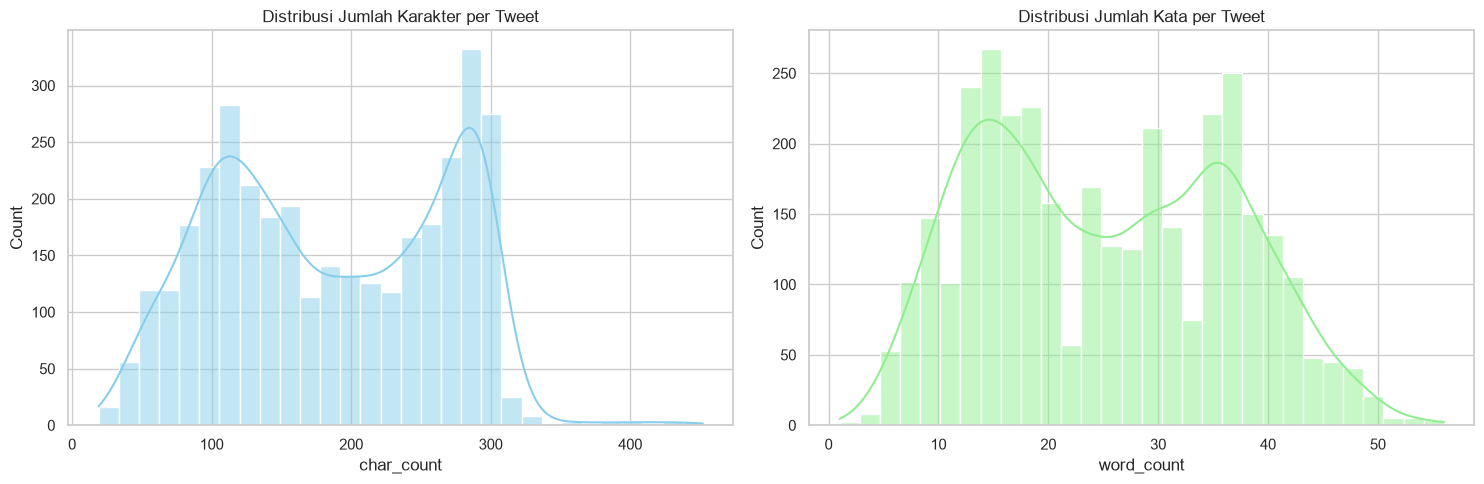

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['char_count'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Jumlah Karakter per Tweet')
sns.histplot(df['word_count'], bins=30, kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribusi Jumlah Kata per Tweet')
plt.tight_layout(); plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_2220\1634005992.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yv, y=xv, palette=pal, ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\1634005992.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yv, y=xv, palette=pal, ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\1634005992.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yv, y=xv, palette=pal, ax=axes[i])


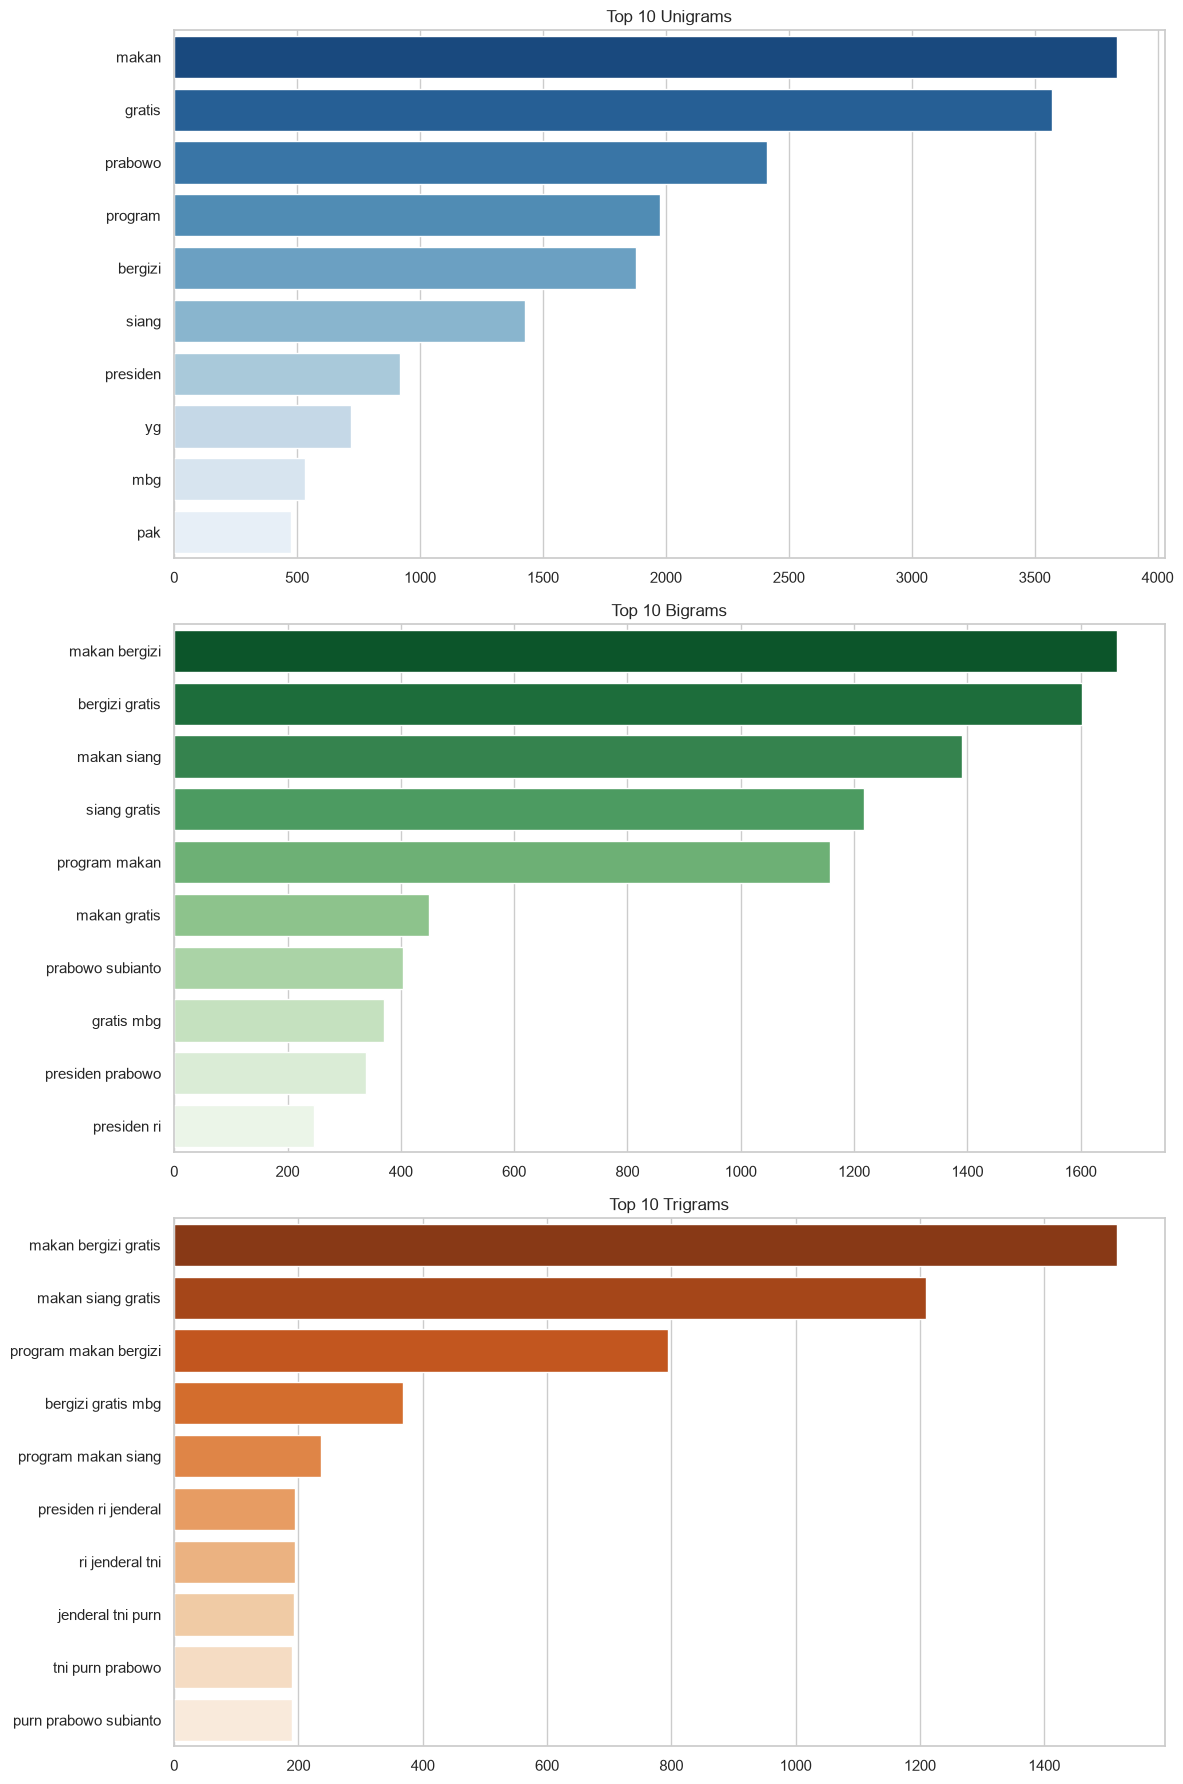

In [53]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['text_for_eda'] = df['full_text'].apply(basic_clean)

def get_top_ngram(corpus, n=None, ngram_range=(1,1)):
    sw = ['di','ke','dari','dan','atau','yang','untuk','ini','itu','dengan','ada','pada']
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=sw).fit(corpus)
    bag = vec.transform(corpus)
    sm = bag.sum(axis=0)
    wf = [(w, sm[0,i]) for w,i in vec.vocabulary_.items()]
    return sorted(wf, key=lambda x: x[1], reverse=True)[:n]

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
for i, (ngr, pal, ttl) in enumerate([
    ((1,1), 'Blues_r', 'Top 10 Unigrams'),
    ((2,2), 'Greens_r', 'Top 10 Bigrams'),
    ((3,3), 'Oranges_r', 'Top 10 Trigrams')
]):
    top = get_top_ngram(df['text_for_eda'], n=10, ngram_range=ngr)
    xv, yv = map(list, zip(*top))
    sns.barplot(x=yv, y=xv, palette=pal, ax=axes[i])
    axes[i].set_title(ttl)
plt.tight_layout(); plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_2220\3222736930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(hc), y=list(hw), palette='viridis', ax=ax)


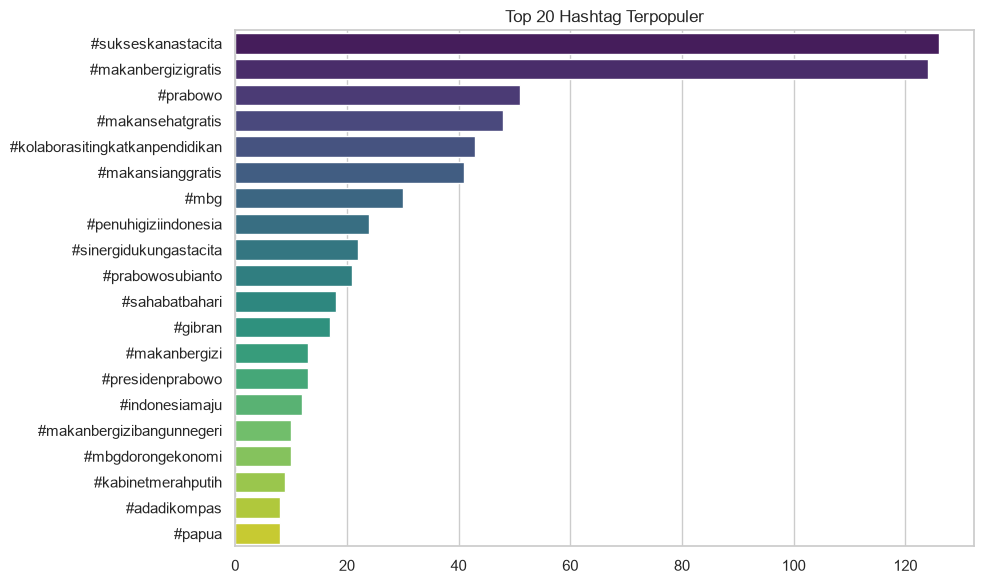

In [54]:
def extract_hashtags(text):
    return re.findall(r'#\w+', str(text).lower())
df['hashtags'] = df['full_text'].apply(extract_hashtags)
all_ht = sum(df['hashtags'].tolist(), [])
ht_freq = Counter(all_ht).most_common(20)
if ht_freq:
    hw, hc = zip(*ht_freq)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=list(hc), y=list(hw), palette='viridis', ax=ax)
    ax.set_title('Top 20 Hashtag Terpopuler')
    plt.tight_layout(); plt.show()


## 3. Preprocessing

In [55]:
normalization_dict = {
    'gak':'tidak','ga':'tidak','nggak':'tidak','ngga':'tidak','gk':'tidak',
    'tdk':'tidak','ndak':'tidak','udh':'sudah','udah':'sudah','dah':'sudah',
    'sdh':'sudah','bgt':'banget','bngt':'banget','sy':'saya','aq':'aku',
    'gue':'saya','gw':'saya','lu':'kamu','lo':'kamu','km':'kamu',
    'yg':'yang','utk':'untuk','dgn':'dengan','dr':'dari','dlm':'dalam',
    'tsb':'tersebut','scr':'secara','krn':'karena','karna':'karena',
    'bs':'bisa','bsa':'bisa','msh':'masih','blm':'belum','sdg':'sedang',
    'lg':'lagi','jg':'juga','tp':'tapi','ttg':'tentang','ny':'nya',
    'klo':'kalau','klu':'kalau','kl':'kalau','spt':'seperti','pd':'pada',
    'spy':'supaya','aja':'saja','aj':'saja','lah':'','deh':'','dong':'',
    'nih':'','wkwk':'','wkwkwk':'','haha':'','hehe':'','ok':'oke',
    'mkn':'makan','mskpn':'meskipun','krg':'kurang','sblm':'sebelum',
    'stlh':'setelah','bbrp':'beberapa','hrs':'harus','smua':'semua',
    'emang':'memang','emg':'memang','mgkn':'mungkin',
    'makasih':'terima kasih','terimakasih':'terima kasih','thx':'terima kasih',
}

# Stopword kustom DIPERLUAS untuk mengurangi tumpang tindih word cloud
custom_stopwords = {
    'mbg','makan','bergizi','gratis','program','prabowo',
    'indonesia','siswa','sekolah','anak','pemerintah','rt',
    'https','http','amp','via','co','twitter','tweet',
    'retweet','follow','like','share','baca','selengkapnya',
    'liputan','berita','foto','video','link','klik',
    # Tambahan: kata lintas sentimen tidak diskriminatif
    'siang','siiang','pak','buat','jadi','sama','presiden',
    'rakyat','banyak','negara','kalau','apa','kerja','anggar',
    'gibran','subianto','purn','tni','jenderal','drs','listyo',
    'sigit','kapolri','inisiasi','nasional','lalu','langsung',
    'jakarta','wakil','layan','masyarakat','hari','orang',
    'kita','mereka','ada','akan','lebih','sudah','juga',
    'dalam','untuk','dengan','dari','tapi','memang','harus',
    'semua','masih','saja','biar','satu','dua','tiga',
}

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()
stop_factory = StopWordRemoverFactory()
sastrawi_stopwords = set(stop_factory.get_stop_words())
all_stopwords = sastrawi_stopwords | custom_stopwords
print(f'Total stopword: {len(all_stopwords)}')

def normalize_text(text):
    tokens = text.split()
    normalized = [normalization_dict.get(t, t) for t in tokens]
    return ' '.join([t for t in normalized if t != ''])

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'&\w+;', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = normalize_text(text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    return ' '.join(tokens)

print('Menjalankan preprocessing pipeline...')
df['clean_text'] = df['full_text'].apply(preprocess)
df = df[df['clean_text'].str.strip() != '']
print(f'Selesai. Data tersisa: {len(df)} baris')


Total stopword: 862
Menjalankan preprocessing pipeline...
Selesai. Data tersisa: 3393 baris


## 4. Pelabelan Sentimen (Lexicon-based)

In [56]:
positive_words = {
    'bagus','baik','sukses','berhasil','manfaat','bermanfaat','positif',
    'dukung','mendukung','setuju','apresiasi','bangga','senang','gembira',
    'harap','harapan','optimis','semangat','suka','hebat','keren','efektif',
    'efisien','tepat','benar','puas','sehat','gizi','nutrisi','sejahtera',
    'maju','progres','berkembang','meningkat','peningkatan','tumbuh','peduli',
    'perhatian','alhamdulillah','syukur','mulia','lanjut','semoga',
    'lancar','solusi','atasi','bantu',
}
negative_words = {
    'buruk','jelek','gagal','kegagalan','masalah','bermasalah','negatif',
    'tolak','menolak','kecewa','mengecewakan','khawatir','takut','sedih',
    'marah','kesal','benci','rugi','kerugian','bahaya','berbahaya','beracun',
    'racun','keracunan','sakit','korupsi','korup','mubazir','percuma','boros',
    'pemborosan','hutang','utang','bangkrut','susah','sulit','kontra','kritik',
    'protes','penolakan','potong','kurang','lambat','telat','terlambat',
    'bohong','hoax','nipu','tipu','manipulasi','kacau','berantakan','hancur',
    'bencana','rugikan','membebani','beban','salah',
}

def lexicon_label(text):
    tokens = set(text.split())
    pos = len(tokens & positive_words)
    neg = len(tokens & negative_words)
    if pos > neg: return 'positif'
    elif neg > pos: return 'negatif'
    else: return 'netral'

df['sentiment'] = df['clean_text'].apply(lexicon_label)
print('Distribusi Sentimen:')
print(df['sentiment'].value_counts())
print('\nPersentase:')
print((df['sentiment'].value_counts(normalize=True)*100).round(2))


Distribusi Sentimen:
sentiment
netral     1874
positif    1180
negatif     339
Name: count, dtype: int64

Persentase:
sentiment
netral     55.23
positif    34.78
negatif     9.99
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_2220\2085499725.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[s.capitalize() for s in sc.index], y=sc.values, palette=cl, ax=axes[1])


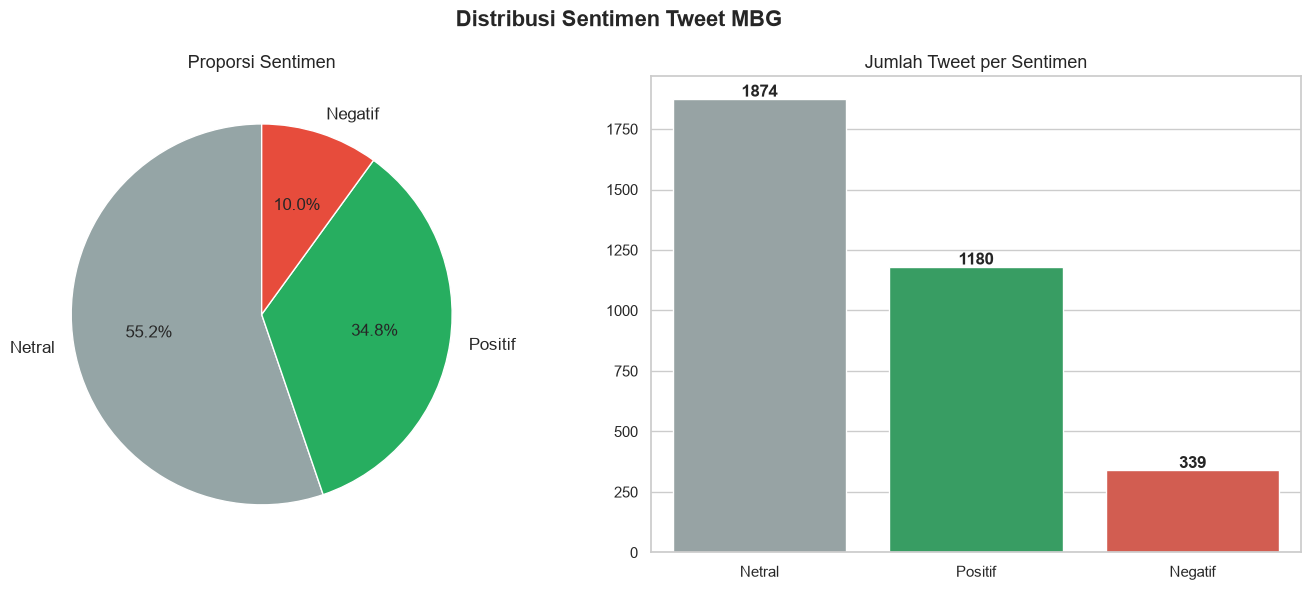

In [57]:
COLORS = {'positif':'#27ae60', 'netral':'#95a5a6', 'negatif':'#e74c3c'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Sentimen Tweet MBG', fontsize=16, fontweight='bold')
sc = df['sentiment'].value_counts()
cl = [COLORS[s] for s in sc.index]
axes[0].pie(sc.values, labels=[s.capitalize() for s in sc.index],
            colors=cl, autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
axes[0].set_title('Proporsi Sentimen', fontsize=13)
sns.barplot(x=[s.capitalize() for s in sc.index], y=sc.values, palette=cl, ax=axes[1])
for i, v in enumerate(sc.values): axes[1].text(i, v+10, str(v), ha='center', fontweight='bold')
axes[1].set_title('Jumlah Tweet per Sentimen', fontsize=13)
plt.tight_layout(); plt.show()


## 5. Ekstraksi Fitur — TF-IDF

In [58]:
tfidf = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.95,
                        ngram_range=(1,2), sublinear_tf=True)
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']
print(f'Shape matriks TF-IDF : {X.shape}')
print(f'Jumlah fitur          : {X.shape[1]}')
print(f'\nDistribusi label:\n{y.value_counts()}')


Shape matriks TF-IDF : (3393, 2000)
Jumlah fitur          : 2000

Distribusi label:
sentiment
netral     1874
positif    1180
negatif     339
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_2220\3215767490.py:18: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\3215767490.py:18: UserWarning: Glyph 9673 (\N{FISHEYE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\3215767490.py:18: UserWarning: Glyph 10006 (\N{HEAVY MULTIPLICATION X}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
d:\code\Analaisis Sentimen MBG\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\code\Analaisis Sentimen MBG\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9673 (\N{FISHEYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\code\Analaisis Sentimen MBG\.venv\Lib\site-packages\IPython\core\pylabtools.py

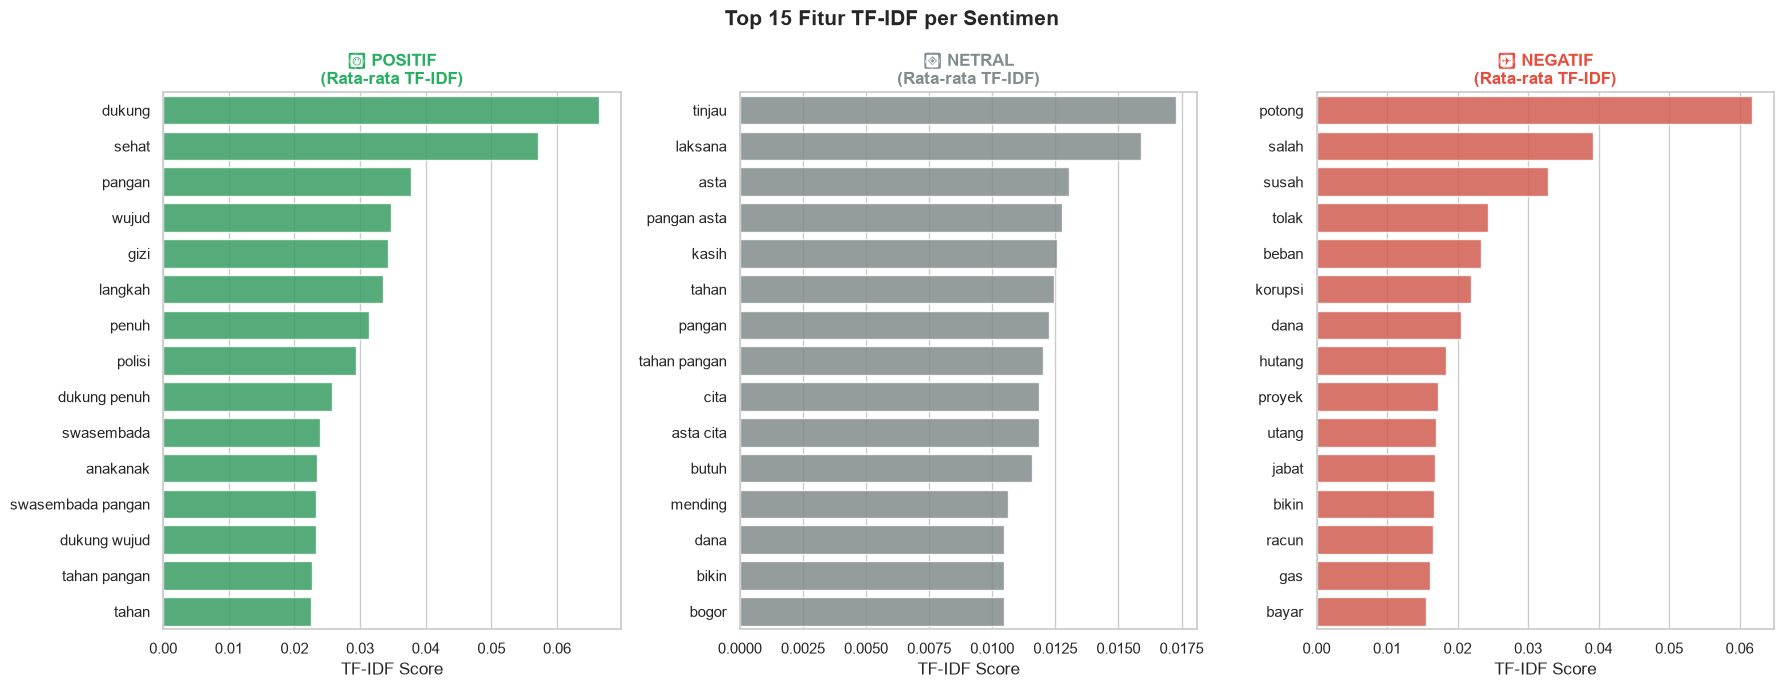

In [59]:
feature_names = np.array(tfidf.get_feature_names_out())
wc_config = {
    'positif': {'color':'#27ae60', 'title':'☀ POSITIF'},
    'netral':  {'color':'#7f8c8d', 'title':'◉ NETRAL'},
    'negatif': {'color':'#e74c3c', 'title':'✖ NEGATIF'},
}
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top 15 Fitur TF-IDF per Sentimen', fontsize=15, fontweight='bold')
for ax, (sentiment, config) in zip(axes, wc_config.items()):
    mask = df['sentiment'] == sentiment
    ts = tfidf.transform(df.loc[mask, 'clean_text'])
    mt = ts.mean(axis=0).A1
    top = mt.argsort()[::-1][:15]
    sns.barplot(x=mt[top], y=feature_names[top], color=config['color'], ax=ax, alpha=0.85)
    ax.set_title(f"{config['title']}\n(Rata-rata TF-IDF)",
                 fontsize=12, fontweight='bold', color=config['color'])
    ax.set_xlabel('TF-IDF Score')
plt.tight_layout(); plt.show()


## 6. Pemodelan Klasifikasi Sentimen

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Data latih : {X_train.shape[0]} sampel')
print(f'Data uji   : {X_test.shape[0]} sampel')
print(f'\nDistribusi kelas (train):')
print(pd.Series(y_train).value_counts())


Data latih : 2714 sampel
Data uji   : 679 sampel

Distribusi kelas (train):
sentiment
netral     1499
positif     944
negatif     271
Name: count, dtype: int64


In [61]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
rec_nb  = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb   = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)
print('='*50+'\nModel 1: Multinomial Naive Bayes\n'+'='*50)
print(f'  Accuracy  : {acc_nb:.4f}\n  Precision : {prec_nb:.4f}\n  Recall    : {rec_nb:.4f}\n  F1-Score  : {f1_nb:.4f}')


Model 1: Multinomial Naive Bayes
  Accuracy  : 0.8027
  Precision : 0.8060
  Recall    : 0.8027
  F1-Score  : 0.7988


In [62]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42, solver='lbfgs')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)
print('='*50+'\nModel 2: Logistic Regression\n'+'='*50)
print(f'  Accuracy  : {acc_lr:.4f}\n  Precision : {prec_lr:.4f}\n  Recall    : {rec_lr:.4f}\n  F1-Score  : {f1_lr:.4f}')


Model 2: Logistic Regression
  Accuracy  : 0.8807
  Precision : 0.8838
  Recall    : 0.8807
  F1-Score  : 0.8804


## 7. Evaluasi Model

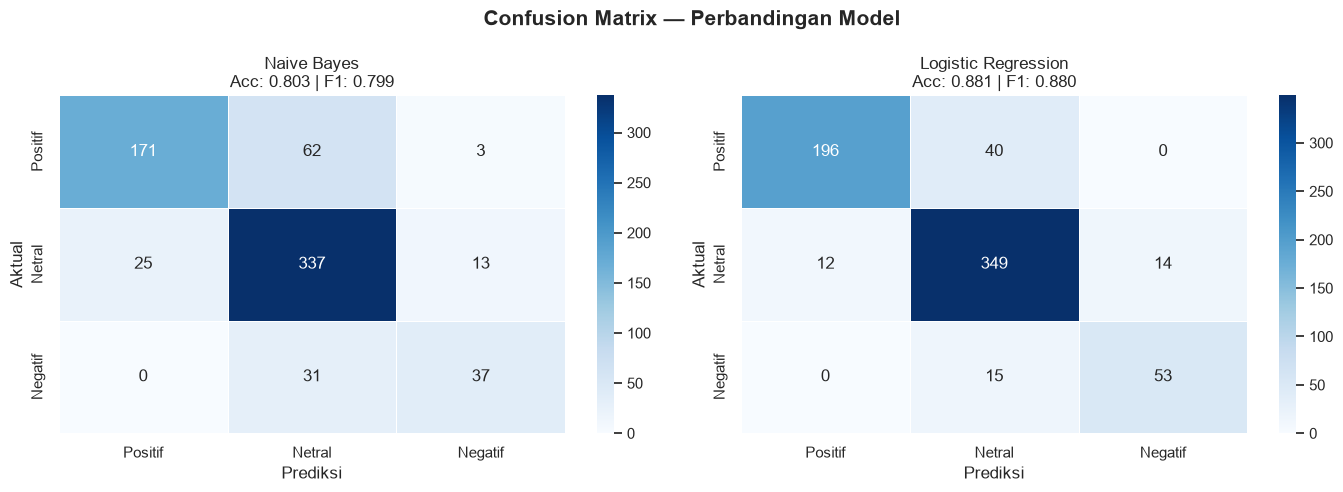

In [63]:
label_order = ['positif', 'netral', 'negatif']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Perbandingan Model', fontsize=15, fontweight='bold')
for ax, (name, pred, acc, f1) in zip(axes, [
    ('Naive Bayes', y_pred_nb, acc_nb, f1_nb),
    ('Logistic Regression', y_pred_lr, acc_lr, f1_lr)
]):
    cm = confusion_matrix(y_test, pred, labels=label_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[l.capitalize() for l in label_order],
                yticklabels=[l.capitalize() for l in label_order],
                ax=ax, linewidths=0.5)
    ax.set_title(f'{name}\nAcc: {acc:.3f} | F1: {f1:.3f}', fontsize=12)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout(); plt.show()


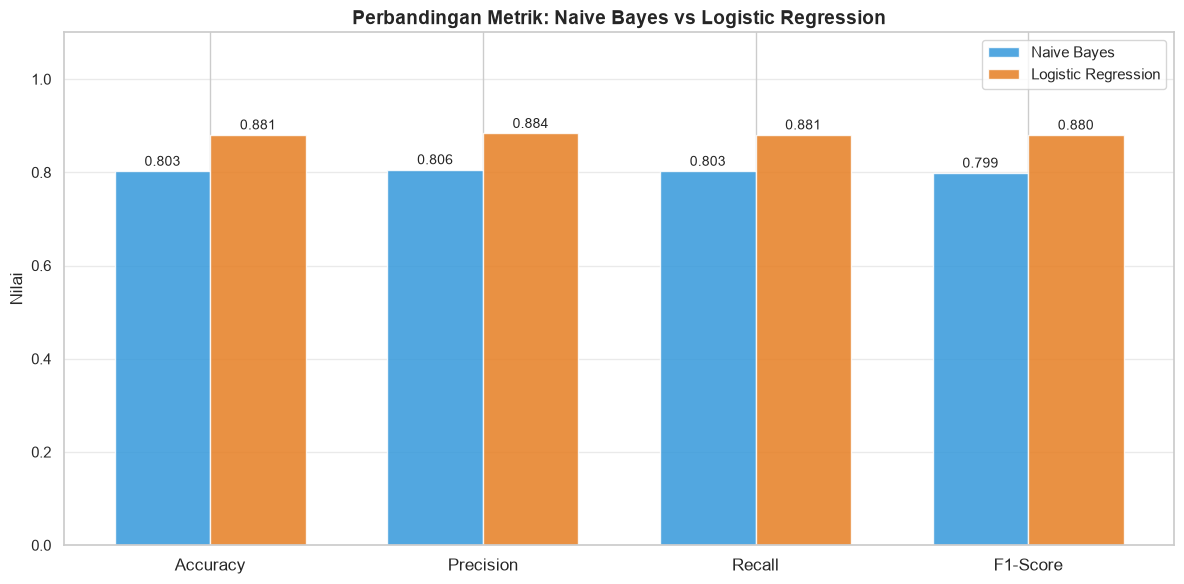

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4); width = 0.35
b1 = ax.bar(x-width/2, [acc_nb,prec_nb,rec_nb,f1_nb], width, label='Naive Bayes', color='#3498db', alpha=0.85)
b2 = ax.bar(x+width/2, [acc_lr,prec_lr,rec_lr,f1_lr], width, label='Logistic Regression', color='#e67e22', alpha=0.85)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1-Score'], fontsize=12)
ax.set_ylim(0, 1.1); ax.set_ylabel('Nilai', fontsize=12)
ax.set_title('Perbandingan Metrik: Naive Bayes vs Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


Classification Report — Logistic Regression

              precision    recall  f1-score   support

     Positif       0.94      0.83      0.88       236
      Netral       0.86      0.93      0.90       375
     Negatif       0.79      0.78      0.79        68

    accuracy                           0.88       679
   macro avg       0.87      0.85      0.85       679
weighted avg       0.88      0.88      0.88       679



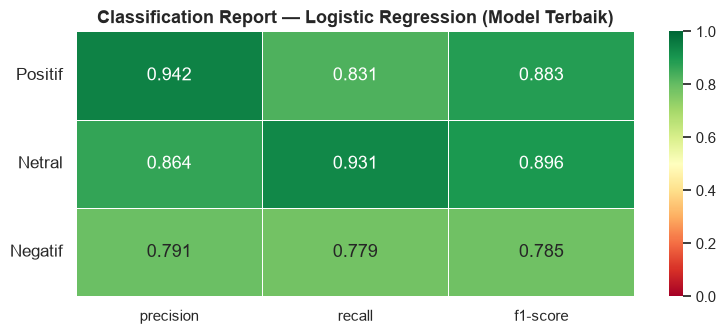

In [65]:
print('Classification Report — Logistic Regression\n')
print(classification_report(y_test, y_pred_lr, labels=label_order,
                             target_names=['Positif','Netral','Negatif'], zero_division=0))
report = classification_report(y_test, y_pred_lr, labels=label_order,
                                target_names=['Positif','Netral','Negatif'],
                                output_dict=True, zero_division=0)
rdf = pd.DataFrame(report).T.iloc[:3][['precision','recall','f1-score']].astype(float).round(3)
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(rdf, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size':13})
ax.set_title('Classification Report — Logistic Regression (Model Terbaik)', fontsize=13, fontweight='bold')
ax.set_yticklabels(['Positif','Netral','Negatif'], rotation=0, fontsize=12)
plt.tight_layout(); plt.show()


## 8. Word Cloud per Sentimen — Berbasis TF-IDF (DIPERBAIKI)

> **Perbaikan dari versi sebelumnya:**
> - **Lama:** `.generate(corpus)` → frekuensi mentah → kata umum muncul di semua panel
> - **Baru:** `.generate_from_frequencies(word_freq)` dengan skor TF-IDF rata-rata per sentimen
> - `max_df=0.85` membuang kata yang muncul di >85% dokumen (lintas sentimen)
> - Stopword diperluas: kata seperti *siang, pak, buat, presiden* dihapus
> - Hasil: setiap panel hanya menampilkan kata yang **benar-benar khas** sentimentnya


C:\Users\HP\AppData\Local\Temp\ipykernel_2220\674526549.py:35: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\674526549.py:35: UserWarning: Glyph 9673 (\N{FISHEYE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\674526549.py:35: UserWarning: Glyph 10006 (\N{HEAVY MULTIPLICATION X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\674526549.py:36: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  plt.savefig('wordcloud_tfidf_mbg.png', dpi=150, bbox_inches='tight',
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\674526549.py:36: UserWarning: Glyph 9673 (\N{FISHEYE}) missing from font(s) Arial.
  plt.savefig('wordcloud_tfidf_mbg.png', dpi=150, bbox_inches='tight',
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\674526549.py:36: UserWarning: Glyph 10006 (\N{HEAVY MULTIPLICATI

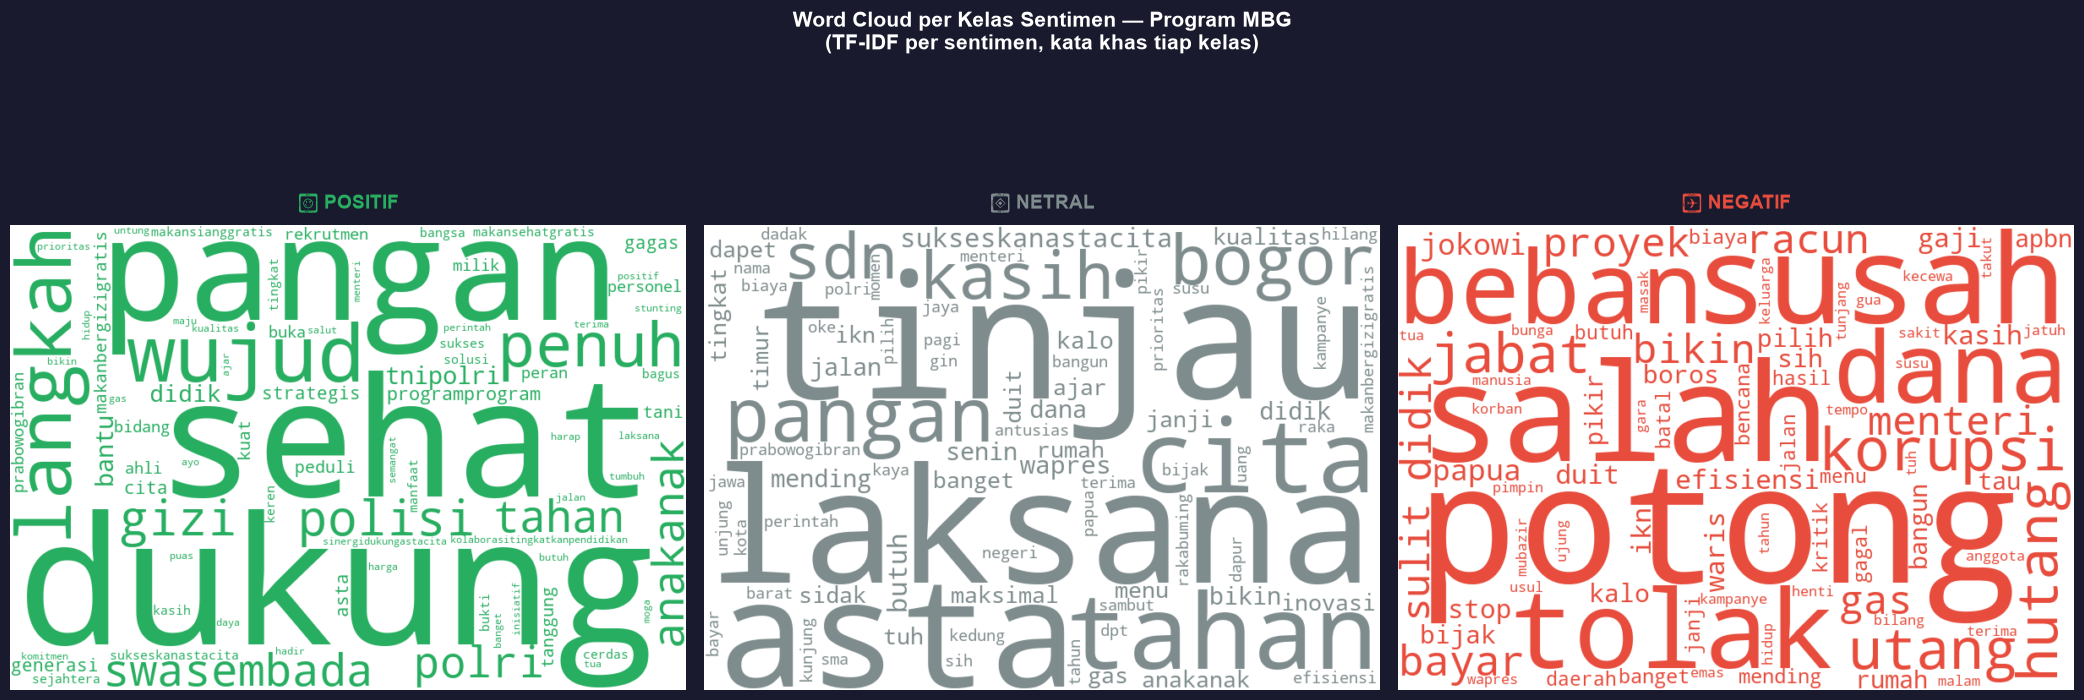

Word cloud disimpan sebagai wordcloud_tfidf_mbg.png


In [66]:
# TF-IDF khusus Word Cloud (unigram, max_df lebih ketat)
wc_tfidf = TfidfVectorizer(
    max_features=3000, min_df=2, max_df=0.85,
    ngram_range=(1,1), sublinear_tf=True
)
wc_tfidf.fit(df['clean_text'])
wc_fn = wc_tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Word Cloud per Kelas Sentimen — Program MBG\n(TF-IDF per sentimen, kata khas tiap kelas)',
             fontsize=15, fontweight='bold', y=1.02, color='white')

for ax, (sentiment, config) in zip(axes, wc_config.items()):
    mask = df['sentiment'] == sentiment
    mat = wc_tfidf.transform(df.loc[mask, 'clean_text'])
    scores = mat.mean(axis=0).A1
    word_freq = {wc_fn[i]: float(scores[i]) for i in range(len(wc_fn)) if scores[i] > 0}

    wc = WordCloud(
        width=800, height=550,
        background_color='white',
        color_func=lambda *a, **kw: config['color'],
        max_words=80, min_font_size=9,
        prefer_horizontal=0.80,
        random_state=42, collocations=False,
    ).generate_from_frequencies(word_freq)  # TF-IDF bukan .generate()

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(config['title'], fontsize=14, fontweight='bold',
                 color=config['color'], pad=12)
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('wordcloud_tfidf_mbg.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Word cloud disimpan sebagai wordcloud_tfidf_mbg.png')


## 9. Top 15 Kata per Sentimen (Frekuensi)

C:\Users\HP\AppData\Local\Temp\ipykernel_2220\2537068689.py:12: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\2537068689.py:12: UserWarning: Glyph 9673 (\N{FISHEYE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_2220\2537068689.py:12: UserWarning: Glyph 10006 (\N{HEAVY MULTIPLICATION X}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
d:\code\Analaisis Sentimen MBG\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\code\Analaisis Sentimen MBG\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9673 (\N{FISHEYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\code\Analaisis Sentimen MBG\.venv\Lib\site-packages\IPython\core\pylabtools.py

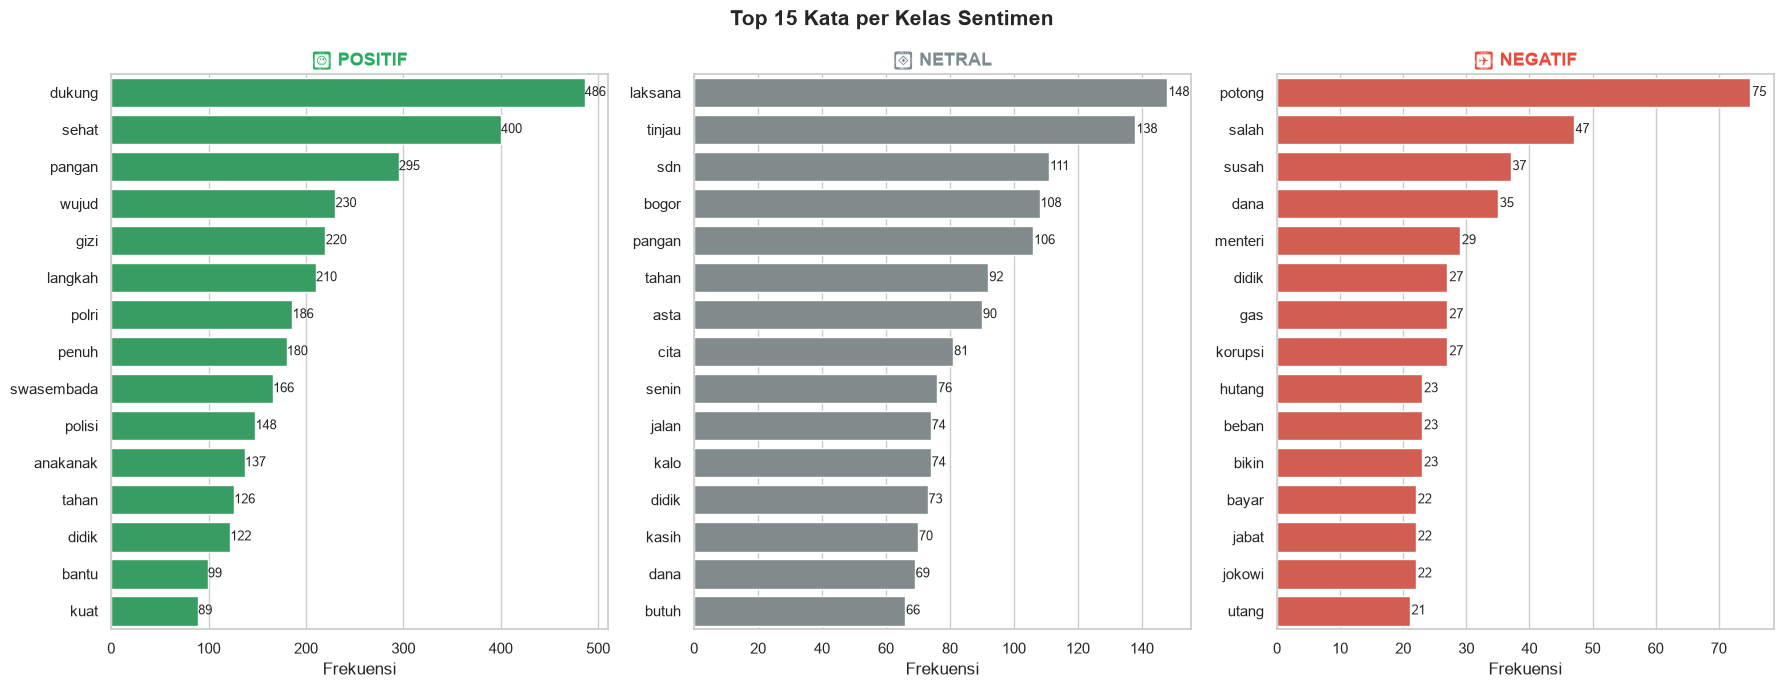

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top 15 Kata per Kelas Sentimen', fontsize=15, fontweight='bold')
for ax, (sentiment, config) in zip(axes, wc_config.items()):
    wa = ' '.join(df[df['sentiment']==sentiment]['clean_text']).split()
    freq = Counter(wa).most_common(15)
    if not freq: continue
    ws, cs = zip(*freq)
    sns.barplot(x=list(cs), y=list(ws), color=config['color'], ax=ax)
    ax.set_title(config['title'], fontsize=13, fontweight='bold', color=config['color'])
    ax.set_xlabel('Frekuensi')
    for i, c in enumerate(cs): ax.text(c+0.3, i, str(c), va='center', fontsize=9)
plt.tight_layout(); plt.show()


## 10. Ringkasan Hasil

In [68]:
print('='*65)
print('RINGKASAN HASIL ANALISIS SENTIMEN PROGRAM MBG')
print('='*65)
print('\n Distribusi Sentimen:')
for s, c in df['sentiment'].value_counts().items():
    pct = c/len(df)*100
    bar = chr(9608) * int(c/30)
    print(f'  {s.capitalize():10}: {c:5d} tweet ({pct:.1f}%) {bar}')
print('\n Hasil Evaluasi Model:')
print(f"{'Model':<25} {'Acc':>8} {'Prec':>8} {'Recall':>8} {'F1':>8}")
print('-'*60)
print(f"{'Naive Bayes':<25} {acc_nb:>8.4f} {prec_nb:>8.4f} {rec_nb:>8.4f} {f1_nb:>8.4f}")
print(f"{'Logistic Regression':<25} {acc_lr:>8.4f} {prec_lr:>8.4f} {rec_lr:>8.4f} {f1_lr:>8.4f}")
best = 'Logistic Regression' if f1_lr >= f1_nb else 'Naive Bayes'
print(f'\n Model Terbaik: {best} (F1-Score: {max(f1_lr, f1_nb):.4f})')
print('\n Word Cloud diperbaiki: TF-IDF per sentimen, tidak tumpang tindih.')


RINGKASAN HASIL ANALISIS SENTIMEN PROGRAM MBG

 Distribusi Sentimen:
  Netral    :  1874 tweet (55.2%) ██████████████████████████████████████████████████████████████
  Positif   :  1180 tweet (34.8%) ███████████████████████████████████████
  Negatif   :   339 tweet (10.0%) ███████████

 Hasil Evaluasi Model:
Model                          Acc     Prec   Recall       F1
------------------------------------------------------------
Naive Bayes                 0.8027   0.8060   0.8027   0.7988
Logistic Regression         0.8807   0.8838   0.8807   0.8804

 Model Terbaik: Logistic Regression (F1-Score: 0.8804)

 Word Cloud diperbaiki: TF-IDF per sentimen, tidak tumpang tindih.


In [69]:
import joblib

# Simpan model Logistic Regression
joblib.dump(lr_model, 'model_lr_mbg.pkl')

# Simpan model Naive Bayes
joblib.dump(nb_model, 'model_nb_mbg.pkl')

# Simpan TF-IDF Vectorizer (karena kedua model menggunakan fitur yang sama)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']